# Paris Airbnb Market Overview

This notebook answers the question: what does the Paris market look like at a high level in terms of price, room type, and occupancy?

Room type performance:
      room_type  listing_count  avg_nightly_price  occupancy_rate_pct
Entire home/apt          43131             325.77               46.58
   Private room           4848             282.06               46.58
     Hotel room            310             386.47               37.75
    Shared room            113              88.35               41.22

Top neighborhoods by true calendar occupancy:
     neighborhood  listing_count  avg_nightly_price  occupancy_rate_pct
     Ménilmontant           2220             189.23               52.61
         Gobelins           1462             218.95               50.96
  Buttes-Chaumont           2309             217.37               50.93
Buttes-Montmartre           4516             239.91               50.11
         Panthéon           1719             322.60               49.79
       Popincourt           3966             245.77               49.72
         Entrepôt           3163             263.38               49.27
    

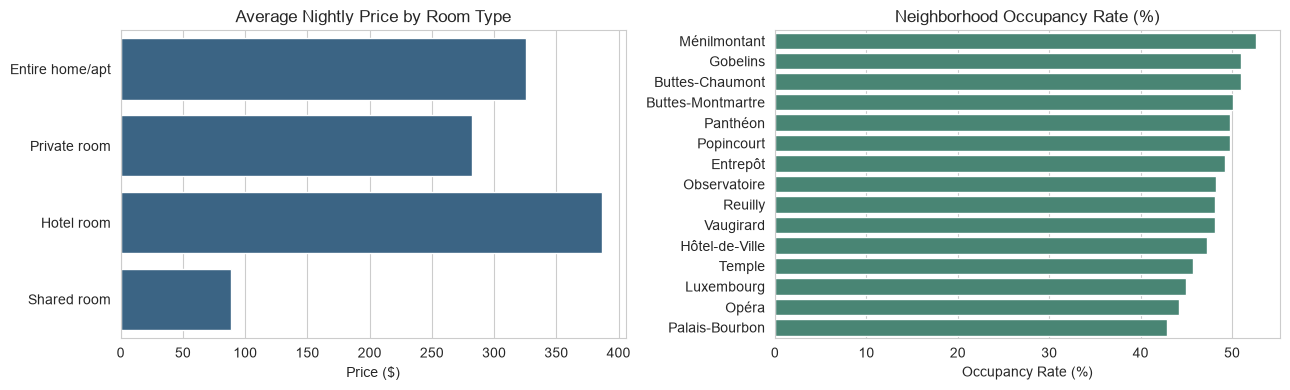

In [2]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv
from sqlalchemy import create_engine

sns.set_style("whitegrid")
load_dotenv(Path(r"C:\Users\LENOVO\Desktop\csv-to-postgres") / ".env")

engine = create_engine(
    f"postgresql+psycopg2://{os.getenv('PGUSER', 'postgres')}:{os.getenv('PGPASSWORD', '')}@"
    f"{os.getenv('PGHOST', 'localhost')}:{os.getenv('PGPORT', '5432')}/{os.getenv('PGDATABASE', 'csv_project')}"
)

# 1. Room Type Performance (Weighted SQL Math)
room_types = pd.read_sql(
    """
    SELECT
        l.room_type,
        COUNT(DISTINCT l.id) AS listing_count,
        ROUND(AVG(l.price)::numeric, 2) AS avg_nightly_price,
        ROUND(
            100.0 * SUM(CASE WHEN c.available = 'f' THEN 1 ELSE 0 END)
            / NULLIF(COUNT(c.date), 0),
            2
        ) AS occupancy_rate_pct
    FROM listings_clean l
    INNER JOIN calendar_clean c ON l.id = c.listing_id
    WHERE l.room_type IS NOT NULL AND l.price IS NOT NULL AND l.price > 0
    GROUP BY l.room_type
    ORDER BY listing_count DESC
    """,
    engine,
)

# 2. Neighborhood Performance (Weighted SQL Math - Matches Excel)
neighborhoods = pd.read_sql(
    """
    SELECT
        l.neighbourhood_cleansed AS neighborhood,
        COUNT(DISTINCT l.id) AS listing_count,
        ROUND(AVG(l.price)::numeric, 2) AS avg_nightly_price,
        ROUND(
            100.0 * SUM(CASE WHEN c.available = 'f' THEN 1 ELSE 0 END)
            / NULLIF(COUNT(c.date), 0),
            2
        ) AS occupancy_rate_pct
    FROM listings_clean l
    INNER JOIN calendar_clean c ON l.id = c.listing_id
    WHERE l.neighbourhood_cleansed IS NOT NULL AND l.price IS NOT NULL AND l.price > 0
    GROUP BY l.neighbourhood_cleansed
    ORDER BY occupancy_rate_pct DESC
    LIMIT 15
    """,
    engine,
)

# Print Outputs
print("Room type performance:")
print(room_types.to_string(index=False))
print("\nTop neighborhoods by true calendar occupancy:")
print(neighborhoods.to_string(index=False))

# Plot Charts
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.barplot(data=room_types, x="avg_nightly_price", y="room_type", ax=axes[0], color="#2f6690")
axes[0].set_title("Average Nightly Price by Room Type")
axes[0].set_xlabel("Price ($)")
axes[0].set_ylabel("")

sns.barplot(data=neighborhoods, x="occupancy_rate_pct", y="neighborhood", ax=axes[1], color="#3f8f78")
axes[1].set_title("Neighborhood Occupancy Rate (%)")
axes[1].set_xlabel("Occupancy Rate (%)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()